# Predicting MLB Playoff Qualification from Full-Season Team Statistics (2015–2023)

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [X] YES - make available

## Link to video

https://www.youtube.com/watch?v=nEdCi9loxAI


## Abstract

This project investigates which regular-season team statistics are the strongest predictors of Major League Baseball (MLB) playoff qualification from 2015 to 2023, excluding the shortened 2020 season. Using 240 team-season observations (30 teams × 8 seasons) collected from FanGraphs via the pybaseball API, we analyze a comprehensive set of offensive metrics (OPS, batting average, runs scored), pitching metrics (ERA, WHIP, runs allowed), and composite metrics (run differential per game, win total).

Our exploratory analysis reveals a clear hierarchy among predictors: Run Differential Per Game provides the strongest separation between playoff and non-playoff teams (median gap of +1.17 runs/game), followed by ERA (median gap of −0.635), with OPS contributing a weaker signal (median gap of +0.035). A correlation heatmap and IQR-based outlier analysis confirm that run differential and pitching quality act as effective gatekeeping metrics, meaning teams with outlier-level poor performance in either virtually never reach the postseason.

To quantify these relationships, we build both a multiple linear regression model predicting team wins (R² ≈ 0.8986) and a logistic regression classifier predicting playoff qualification directly. The logistic model, evaluated with 5-fold cross-validation, achieves strong classification accuracy (0.88), with Run Differential Per Game emerging as the dominant predictor in both models. A Random Forest comparison and feature importance analysis further validate these findings. Together, the results confirm our hypothesis that run differential is the single most informative statistic for predicting whether an MLB team will reach the playoffs, with pitching quality (ERA) as a close secondary factor and offensive production (OPS) as a supplementary contributor.


## Authors

- Lincoln Wirschem: Data Collection and Wrangling, Conceptualization, Writing Background
- Ricardo Hernandez: Data Collection/Ethics, Linear Regression
- Vedant Patel: Writing - review & editing, EDA, Outlier Analysis
- Aleksey Dykhno: Planning, Conclusion
- Yash Goel: Ethics, Data Summary, EDA, Visualizations, Video

## Research Question

**From 2015 to 2023 (excluding the shortened 2020 season), which full-season team statistics — spanning offensive metrics (such as OPS, run differential, HR, and RBI), pitching metrics (such as ERA and WHIP), and win-loss record — are the strongest indicators of MLB playoff qualification, as measured by their predictive power in regression and classification models?**


## Background and Prior Work

Throughout the existence of Major League Baseball, there have been increased investments into franchises to create more revenue by having more competitive teams. MLB owners often invest money into star players to bring attention and fans to their team, which makes them profit and repeats this cycle. One of the main metrics to record how well a team is doing, is if they are able to make the League's playoffs, which only a select group of teams make. All with the ultimate goal of winning the World Series Championship.

A key question in baseball analytics is: which regular-season statistics best predict whether a team reaches the postseason? Understanding which metrics most strongly separate playoff teams from non-playoff teams can inform front office decisions, player acquisition strategies, and fan expectations. To answer this, we analyze full-season team-level statistics across multiple seasons and evaluate their predictive power as indicators of playoff qualification.

Prior work that we found each began with defining what the benchmarks for the data analysis were <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2), and what features to create the prediction from. The most common ones were from the Final Project at Stanford, created by Randy Jia, Chris Wong, and David Zeng, where they selected BA, RBI, OBP, ERA, H, E, and Win% for each team to be the metrics they used in their predictive model. They found that these metrics were representative of the state of each MLB team within their respective time frame, lending support to the idea that a well-chosen set of full-season statistics can reliably classify playoff teams.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)

Dr. Gregory Wood and David Marmor created an inferential model about correlations between teams' regular-season statistics versus their performance during the playoff season. <a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4) They found that the correlation coefficient for regular-season statistics versus playoff outcomes was extremely close to 0, suggesting that the randomness of a short playoff series makes playoff performance hard to predict from regular season stats. This is directly relevant to our project: rather than trying to predict playoff performance, we focus on the more tractable question of predicting playoff *qualification*, which is determined by the full 162-game regular season where the large sample size reduces randomness.

This was similar to another reference that we found, a research article by Stanley Rothman, where he created a predictive model of how many wins a team would get depending on Runs Allowed and Runs Scored, using a linear regression. <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) They concluded that their two predictive models "both were effective in predicting the actual win totals for the 2013 MLB season," reinforcing the predictive value of run-based metrics at the team level.

The most useful reference that we found is the Playoff Prediction section of the Fangraphs website.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) Fangraphs calculates the playoff odds for each team after each game is played, blending team statistics with remaining schedule. This is useful context for our work because it confirms that full-season statistics are strong enough inputs to generate meaningful playoff probability estimates — which is the same assumption underlying our classification approach.

Statistic Legend:
-  Batting Average = Hits / At Bats
- Home Runs = 4 Bases, an RBI and a Run for this batter
- RBIs = Runs earned by a Hit or a Sacrifice Fly
- Runs scored = Total times a player crosses home plate
- Stolen Bases = Runner advancing from base to base (not including home plate to first base)
- Wins = Team Wins
- ERA = Earned Run Average, Earned Runs / Innings Pitched
- WHIP = Walks + Hits per Innings Pitched
- OBP = On Base Percentage, counts if batter gets on base (aka Hits, Hit by Pitch, or
- Strikeouts = Swinging strikeouts or Looking Strikeouts
- Saves = Pitcher Save, finishes a game for the winning team under specific conditions



Citation:
1. <a name="cite_note-1"></a> [^](#cite_ref-1) Rothman, Stanley. "A New Formula to Predict a Team's Winning Percentage." Society for American Baseball Research, 31 Jan. 2024, https://sabr.org/journal/article/a-new-formula-to-predict-a-teams-winning-percentage/
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Jia, Randy, et al. Predicting the Major League Baseball Season, https://cs229.stanford.edu/proj2013/JiaWongZeng-PredictingTheMajorLeagueBaseballSeason.pdf Accessed 3 Feb. 2026. 
3. <a name="cite_note-2"></a> [^](#cite_ref-3) "MLB Playoff Odds." FanGraphs Baseball, www.fangraphs.com/standings/playoff-odds/fg/div?date=2024-03-27. Accessed 3 Feb. 2026. 
4. <a name="cite_note-2"></a> [^](#cite_ref-4)  Dr. Gregory Wood and David Marmor. "Predicting the Playoffs." Fangraphs Community Blog, 30 Aug. 2017, https://community.fangraphs.com/predicting-the-playoffs/. 
 


## Hypothesis


We expect that full-season run differential per game will be the strongest indicator of MLB playoff qualification, as it captures both offensive production and pitching/defensive effectiveness in one metric. Teams with a positive run differential are likely winning more games and therefore more likely to reach the postseason.

Among offensive metrics, we expect OPS to be a stronger predictor than batting average alone, since it better captures a team's ability to both reach base and hit for power. On the pitching side, we expect ERA to be a stronger predictor than WHIP, as it directly measures the runs a team allows rather than a rate of baserunners.

Overall, we hypothesize that a combination of run differential, OPS, ERA, and team win total will together provide strong classification performance for predicting playoff qualification, with run differential contributing the most predictive weight.

# Data

### Data overview

Our dataset contains full-season team-level statistics for all 30 MLB teams across 8 seasons (2015–2023, excluding the shortened 2020 season), totaling **240 team-season observations**. The data was collected programmatically from FanGraphs using the `pybaseball` Python package, which provides access to both batting and pitching statistics at the team level.

Each observation includes offensive metrics (AVG, OBP, SLG, OPS, R, HR, RBI, BB, SO), pitching metrics (ERA, WHIP, W, L, SV, IP, SO, runs allowed), and derived metrics (Run Differential, Run Differential Per Game). A binary `Made_Playoffs` indicator was manually compiled from historical records for each team-season, as playoff qualification data is not directly available through pybaseball.

The raw FanGraphs data contained over 300 batting columns and 390 pitching columns per team per season. We reduced this to approximately 30 key variables during wrangling, selecting features grounded in the baseball analytics literature and our research question. Full details on variable definitions and data characteristics are provided in the sections below.




### 1. The Ideal Dataset

A. The ideal dataset would include comprehensive team-level performance statistics for all MLB teams across multiple seasons. It would contain both offensive and pitching metrics that influence team success and playoff probability.

##### Key variables would include:

- Offensive Metrics

- Batting Average (AVG)

- On-Base Percentage (OBP)

- Slugging Percentage (SLG)

- On-Base Plus Slugging (OPS)

- Home Runs (HR)

- Runs Batted In (RBI)

- Runs Scored (R)

- Stolen Bases (SB)

- Pitching Metrics

- Earned Run Average (ERA)

- Walks + Hits per Inning Pitched (WHIP)

- Strikeouts (SO)

- Saves (SV)

- Advanced Metrics

- Wins Above Replacement (WAR)

- Team run differential

- Playoff probability (if available)

B. The ideal dataset would have observations from every single team (30 teams) for each season necessary (2015–2023 not including 2020 shortened season) to extract full-season team statistics. Meaning we should have around 240 different observations for these teams.

C. To get the ideal data, it must be scraped from online, directly downloadable, or collected directly from an API. We would have to search for the data by year, and collect all the team data for that specific season, and then eventually wrangle it to combine the season team datasets together.

D. This data would be organized into .csv files, where we would first separate the team pitching statistics from the team batting statistics. Then these datasets could be combined only keeping what is necessary for the EDA later down the line.


## 2. Our Dataset

The data will be collected from FanGraphs, which can be viewed from the website: https://www.fangraphs.com/leaders.aspx

No permission is required for academic, non-commercial use.

We will use the Python package pybaseball which is a Python API wrapper for baseball data sources including FanGraphs, which allows us to programmatically retrieve team-level statistics. The data can be downloaded and collected directly into CSV files using the functions given in the package.

Data Size: 

We are using team-level data from the 2015–2023 MLB seasons, excluding 2020 due to the shortened season, which gives us 8 years worth of data, and since there are 30 MLB teams in these seasons, we have 240 different actual observations. With the pitching data, there was 390 different variables/statistics tracked for each team, and for hitting data it was 319 different variables. This is too large for what we need, so we are wrangling it to be smaller and only for necessary information.

For each team, we will extract statistics from the entire season, and then using these most important variables, craft a smaller dataframe using Pandas to explore the data analysis down the line. After the data is cleaned and organized by team and season, we will visualize our data using graphs (bar charts, scatterplots, correlation heatmaps).

Most Important Variables Used:
Batting metrics (AVG, OBP, OPS, HR, R, RBI), 
Pitching metrics (ERA, WHIP, SO, SV), 
Wins (W), 
Wins Above Replacement (WAR)...to be continued if necessary

Drawback of Dataset: This dataset does not include whether a team made it to the playoffs that year or not, so our main task for creating another dataframe would be to grab the playoff information and put it into a .csv file.

### MLB Team Season Statistics and Playoff Qualification (2015–2023, excluding 2020) via Pybaseball FanGraphs Data


#### Dataset Overview

This dataset contains season-level statistics for all 30 Major League Baseball (MLB) teams across 8 seasons, 2015 through 2023, with 2020 excluded due to that year's COVID-shortened 60-game season being incomparable to a standard 162-game schedule. Each of the 240 rows represents one team's full season, covering how well they hit (offensive metrics), how well their pitchers performed (pitching metrics), and overall outcomes like wins, losses, and playoff qualification.
Offensive (Batting) Metrics
Plate Appearances (PA) counts every time a batter stepped to the plate. At-Bats (AB) is a narrower version that excludes walks and sacrifice plays, since those are not counted against a batter in traditional scoring. Runs (R) is simply how many times the team's players crossed home plate. Teams average about 731 per season, or roughly 4.5 per game. Hits (H) counts times a batter reached base via a clean hit, while Home Runs (HR) tracks how many were hit out of the park, averaging a notably high 192 per team per season and reflecting the power-hitting era of the late 2010s. Runs Batted In (RBI) counts how many runs a batter drove in, though it partly depends on how many teammates were already on base, making it as much a product of lineup context as individual skill. Walks (BB, or Base on Balls) reflect plate discipline, meaning batters who do not chase pitches outside the strike zone, while Strikeouts (SO) represent outs recorded by striking out swinging or looking. The league average of 1,356 strikeouts per team per season is historically high, reflecting a well-documented league-wide trend over this era.
Batting Average (AVG) is hits divided by at-bats and is the most traditional hitting statistic. A .300 average is excellent, .250 is league average (matching the dataset mean), and below .230 is poor. On-Base Percentage (OBP) is considered more complete because it also counts walks and hit-by-pitches, capturing every way a batter can avoid making an out. The league average here is .319, and above .350 is considered very good. Slugging Percentage (SLG) measures power by weighting hits based on bases earned. A single counts as 1, a double as 2, a triple as 3, and a home run as 4, and the total is then divided by at-bats. On-Base Plus Slugging (OPS) adds OBP and SLG together into one number that captures both plate discipline and power. The league average OPS in this dataset is .733. For reference, .800 is very good and .900 or above is elite.

#### Pitching Metrics

Earned Run Average (ERA) is the central pitching statistic, measuring how many earned runs a pitching staff gives up per 9 innings pitched. "Earned" means the run was not caused by a defensive error. A 3.00 ERA is excellent, 4.00 is roughly league average (the dataset mean is 4.22), and above 5.00 is poor. Games Started (GS) is essentially 162 in a full season, one starter per game. Saves (SV) are awarded to relievers who enter a close game late and preserve the lead. Innings Pitched (IP) is the total innings the staff threw across the season, averaging about 1,440, which is close to 162 games multiplied by 9 innings. Hits, Walks, Earned Runs, and Home Runs Allowed are the pitching counterparts to the offensive stats, tracking what the pitching staff gave up rather than produced.
Walks plus Hits per Inning Pitched (WHIP) is the most intuitive pitching summary statistic, measuring how many baserunners a staff allowed per inning on average. A WHIP of 1.00 means one baserunner per inning, which is excellent. The league average here is 1.31, and above 1.50 means the staff is consistently putting runners on base and will likely give up a lot of runs.

#### Outcome Metrics

Run Differential is total runs scored minus total runs allowed across the season. A positive number signals a good team, and the range in this dataset goes from -339 to +334. Run Differential Per Game normalizes this figure by games played for easier comparison across seasons. Made Playoffs is a binary indicator, where 1 means the team reached the postseason and 0 means they did not. About 35% of team seasons in the dataset ended in a playoff appearance, consistent with MLB's format of roughly 10 of 30 teams qualifying each year.

#### Potential Concerns

The most important issue is that the dataset spans a period of significant rule changes. The 2023 season introduced a pitch clock, larger bases, and restrictions on defensive shifts, meaningfully changing the pace and statistical outcomes of games. Batting averages rose and strikeouts fell relative to prior years as a result. Any model trained on the full dataset should account for the fact that the sport itself changed partway through the window.
Because statistics are aggregated at the team level, individual player contributions are invisible. A team with a high home run total might have one superstar carrying the load or a balanced lineup, and you cannot tell from this data alone. Additionally, the playoff indicator does not distinguish between first-round exits and World Series champions, so postseason performance itself cannot be studied here. Finally, with only 240 observations, the sample is relatively small for complex modeling, and patterns driven by a handful of unusual seasons or outlier teams could appear more meaningful than they actually are.

## Data Imported

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('./modules')
import get_data
## checking to see if you have pybaseball installed, and if not it will install
# using this try catch, it doesn't show the terminal output which was long
try:
    import pybaseball
except ImportError:
    !pip install pybaseball
    import pybaseball
import pandas as pd
import numpy as np
from pybaseball import team_batting, team_pitching, standings
import warnings
warnings.filterwarnings('ignore')


# Final Dataset After Wrangling



The code that handles the full data collection, cleaning, and preparation pipeline for the project is in `02-EDACheckpoint.ipynb`. It starts by using the pybaseball package to pull team-level batting and pitching statistics from FanGraphs for each season from 2015 to 2023, excluding 2020. It loops through each season, collects the data for all 30 teams, adds a season label, and combines everything into two large dataframes; one for batting and one for pitching, resulting in 240 observations each. Since pybaseball does not provide playoff qualification data in a clean format, playoff teams for each season were manually entered into a dictionary and converted into a separate dataframe, marking each team-season with a 1 (made playoffs) or 0 (did not).


From there, the code cleans both datasets by stripping whitespace and removing any duplicate entries, then trims each down to only the most relevant columns needed for the analysis. It renames conflicting column names between the batting and pitching data, merges the two together on team and season, and calculates Run Differential Per Game by subtracting runs allowed from runs scored and dividing by games played. Finally, the playoff data is merged in, any rows with missing values in the key variables are dropped, and the completed dataset is saved as a processed CSV file ready for analysis.

##### -The code for the data collection and wrangling was removed to save space, find it in `02-EDACheckpoint.ipynb`



## Exploratory Data Analysis

**Note:** The code to EDA is lengthy, so we saved our figures as images into `results/` and reload them here. To see the code responsible for EDA analyses, see `02-EDACheckpoint.ipynb`.


### Section 1: Metric Distributions — What Shape Does Our Data Take?

We plot histograms with kernel density estimate (KDE) overlays for our three most important metrics: **Run Differential Per Game**, **OPS**, and **ERA**. Each histogram overlays playoff teams (blue) against non-playoff teams (red) so we can immediately see whether the two groups separate or heavily overlap.

**Why these three metrics** 

Because they capture the three dimensions of our hypothesis: overall team quality (Run Diff/Game), offensive production (OPS), and pitching effectiveness (ERA). If our hypothesis is correct, we expect playoff teams to cluster toward positive run differential, higher OPS, and lower ERA relative to non-playoff teams.

Dataset: 240 team-seasons | 8 seasons | 30 teams
Playoff appearances :  84  (35.0%)
Missed playoffs     : 156  (65.0%)


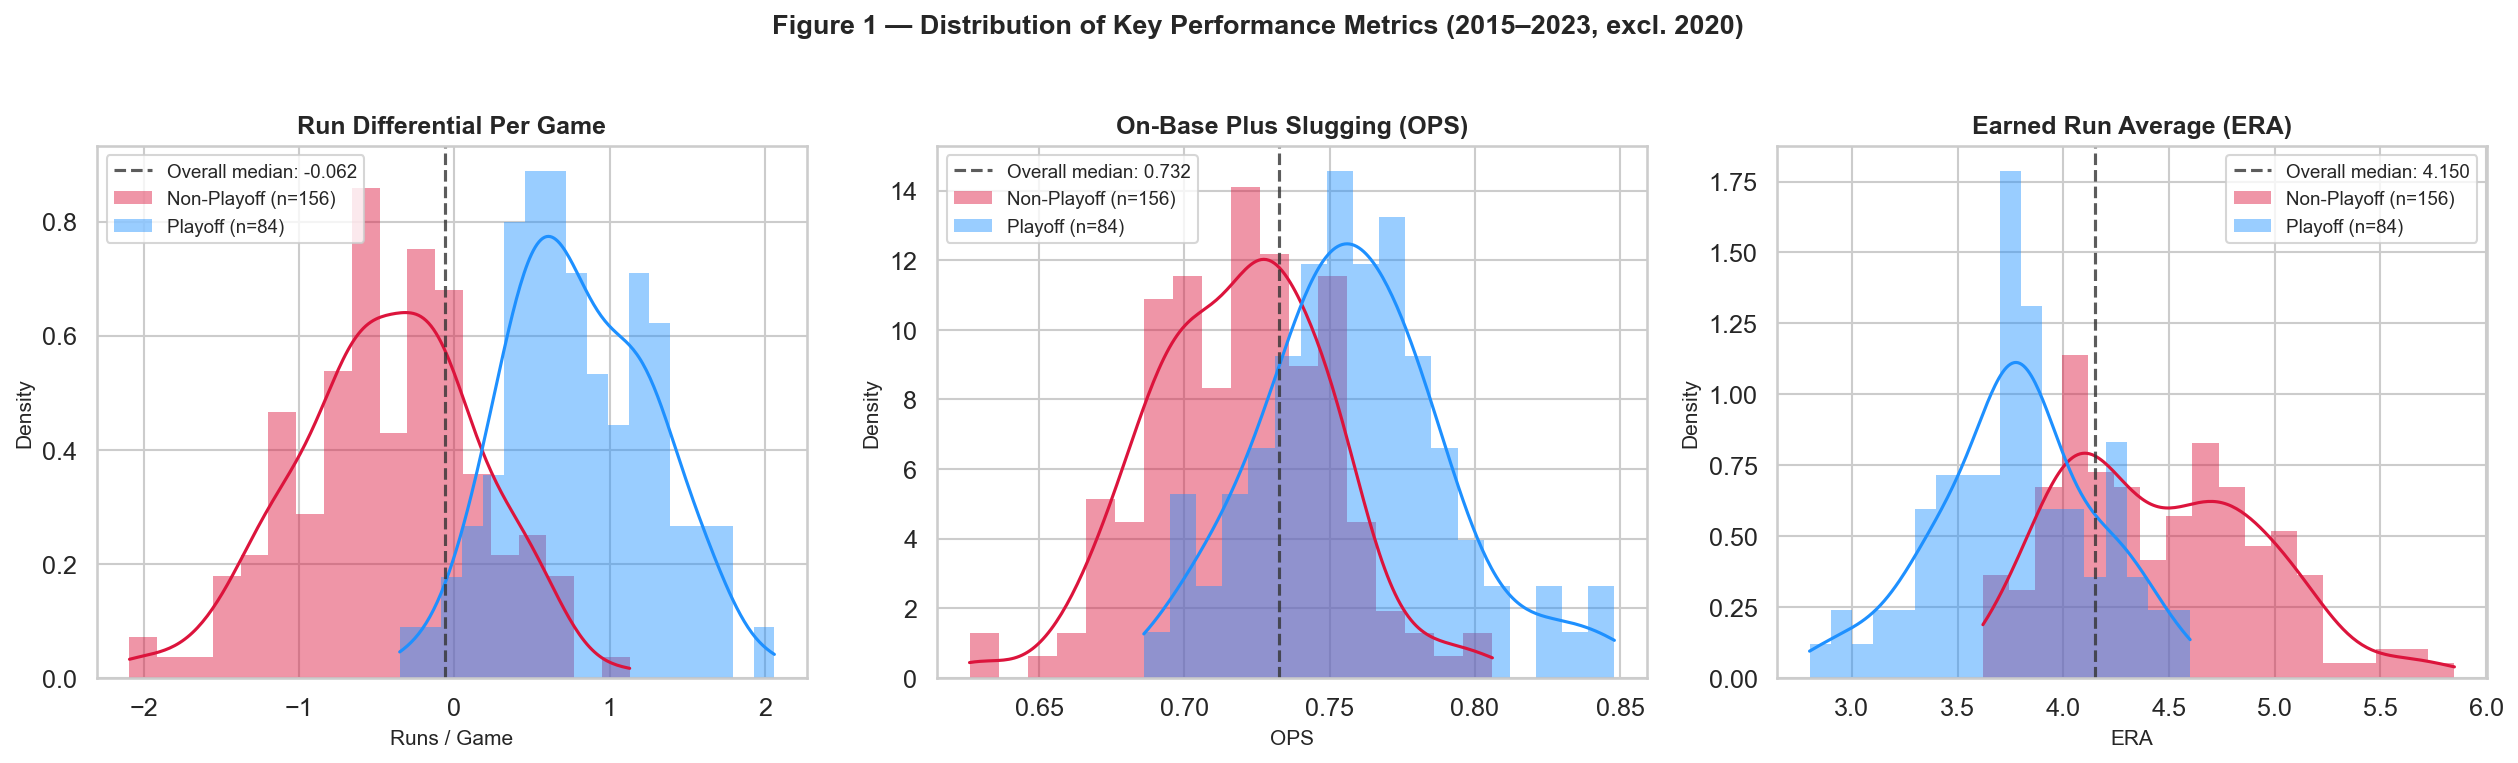

In [2]:
from IPython.display import Image, display

df = pd.read_csv('data/02-processed/mlb_prediction_dataset.csv')

dataset_size = str(df.shape[0])
seasons_count = str(df['Season'].nunique())
teams_count = str(df['Team'].nunique())
print("Dataset: " + dataset_size + " team-seasons | " + seasons_count + " seasons | " + teams_count + " teams")

playoff_sum = df['Made_Playoffs'].sum()
playoff_pct = df['Made_Playoffs'].mean() * 100
print("Playoff appearances : " + str(playoff_sum).rjust(3) + "  (" + str(round(playoff_pct, 1)) + "%)")

missed_sum = (df['Made_Playoffs'] == 0).sum()
missed_pct = (1 - df['Made_Playoffs'].mean()) * 100
print("Missed playoffs     : " + str(missed_sum).rjust(3) + "  (" + str(round(missed_pct, 1)) + "%)")

display(Image(filename='results/fig1_metric_distributions.png'))


## Figure 1 Interpretation:

The three histograms reveal clear and different degrees of separation between playoff and non-playoff teams.

- **Run Differential Per Game** (overall median: −0.062) shows the strongest and cleanest separation. The non-playoff KDE (red) peaks around −0.5 runs/game and spans a wide range into deeply negative territory, while the playoff KDE (blue) peaks around +0.5 runs/game. The two curves cross near zero, with very little overlap, meaning that a team that consistently outscores its opponents over a full season is almost certainly playoff bound. The overall median sitting just below zero (−0.062) reflects the fact that the 156 non-playoff observations pull the midpoint slightly leftward relative to the balanced mean.

- **OPS** (overall median: 0.732) shows the least separation of the three metrics. Both the non-playoff and playoff distributions are approximately bell-shaped and centered near 0.72–0.74, with the playoff group shifted only slightly right. The two KDE curves overlap almost entirely, indicating that team OPS alone is a weak differentiator and that there are many high-OPS non-playoff teams and many low-OPS playoff teams. OPS contributes predictive signal, but it cannot separate the groups on its own.

- **ERA** (overall median: 4.150) shows moderate separation. The playoff KDE (blue) is tighter and peaks earlier, around 3.7–3.9, while the non-playoff KDE (red) is flatter and spreads noticeably further right toward 4.5–5.5+. This right skew in the non-playoff distribution is driven by a handful of particularly poor pitching staffs in individual seasons. The separation here is more visible than for OPS but less clean than for run differential.

Together, the three histograms establish a clear hierarchy: **Run Differential Per Game > ERA > OPS** in terms of how significantly each metric contributs to separating a playoff team from a non-playoff team. This is consistent with our hypothesis, and motivates using run differential as the anchor variable in our future classification model.

### Section 2: Outlier Detection - Are playoff teams statistically distinguishable from non-playoff teams?

Since Boxplots have the ability to show us the center and spread of larger datasets, here we ar going to plot boxplots for **Run Differential Per Game** and **OPS**. They will be distinguished by playoff status, with individual team-seasons overlaid as jittered points.

**What exactly are we looking for?** Well, the most important detail to catch will be a clear vertical gap between the two boxes - because this confirms a metric that reliably will differentiate playoff teams from non-playoff teams. Individual dots outside the whiskers are outlier seasons, the most analytically interesting cases. This is becuase of the fact a non-playoff dot with very high OPS would represent a team that hit extremely well but had catastrophic pitching, illustrating why great offense alone does not guarantee postseason success. The medians below each plot detail the exact gap between groups.

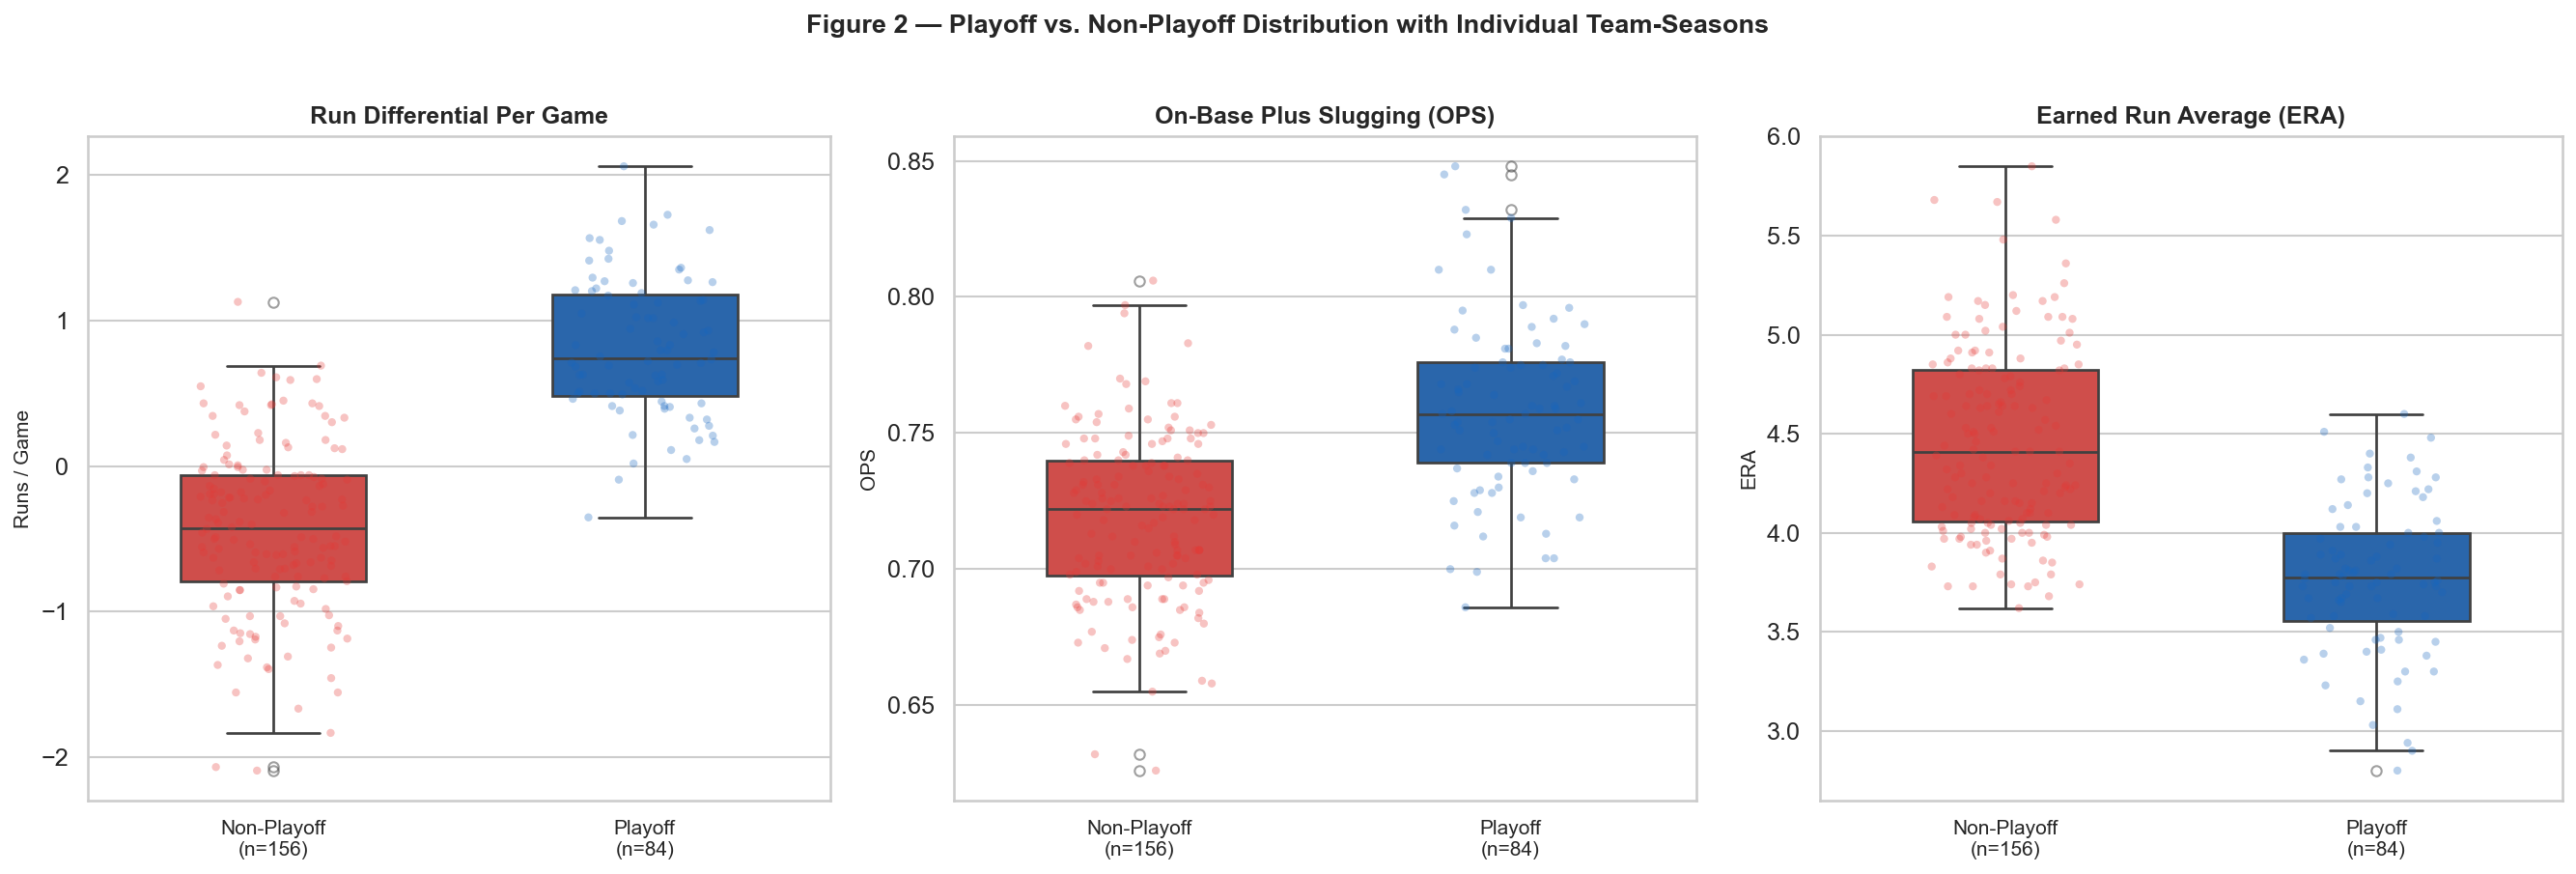

In [3]:
display(Image(filename='results/fig2_boxplots.png'))

In [4]:
df = pd.read_csv('data/02-processed/mlb_prediction_dataset.csv')

## GROUP MEDIANS
print("Group medians:")
print("Metric:                   Non-Playoff      Playoff      Delta (Playoff - Non)")
for col in ['Run_Diff_Per_Game', 'OPS', 'ERA']:
    if col in df.columns:
        g = df.groupby('Made_Playoffs')[col].median()
        non_playoff_val = round(g[0], 3)
        playoff_val = round(g[1], 3)
        diff_val = round(g[1] - g[0], 3)
        diff_str = "+" + str(diff_val) if diff_val > 0 else str(diff_val)
        print(col.ljust(24) + str(non_playoff_val).rjust(15) + str(playoff_val).rjust(13) + diff_str.rjust(20))

Group medians:
Metric:                   Non-Playoff      Playoff      Delta (Playoff - Non)
Run_Diff_Per_Game                -0.426        0.744               +1.17
OPS                               0.722        0.757              +0.035
ERA                                4.41        3.775              -0.635


## Figure 2 Interpretation:

The boxplots and printed medians together quantify the separation between playoff and non-playoff teams across all three key metrics.

- **Run Differential Per Game** shows the most dramatic separation. The non-playoff median is −0.426 runs/game and the playoff median is +0.744 runs/game — a gap of +1.17 runs per game. The two boxes barely overlap in their interquartile ranges, making this the clearest visual separator of the three. A handful of non-playoff outlier dots appear with positive run differentials, representing strong teams that nonetheless fell short in a tough division race. A few playoff dots near zero confirm that elite pitching can carry a team to the postseason even without a run-scoring advantage.

- **OPS** shows a real but modest gap: non-playoff median 0.722 vs. playoff median 0.757, a difference of a measly +0.035. The two inter-quartile ranges overlap substantially, meaning many high-OPS teams missed the playoffs and many low-OPS teams qualified. This reinforces our previous figure observations that offensive production alone is insufficient, meaning that a team can hit well yet give up more runs than it scores if the pitching staff is subpar.

- **ERA** shows a meaningful gap in the opposite direction (lower ERA is better): non-playoff median 4.41 vs. playoff median 3.775, a difference of −0.635 earned runs per game. The playoff box sits entirely lower, with only a small overlap in the tails. This confirms that pitching quality is a strong playoff differentiator, though the gap is smaller in absolute magnitude than the run differential separation.

Together, the three panels reinforce the hierarchy we established in Figure 1: **Run Differential Per Game** is the single most decisive separator, with **ERA** a clear second and **OPS** with a weaker contribution to playoff chances.

### Section 3: Variable Relationships: Which Metrics Correlate Most with Playoff Success?

We build a **correlation heatmap** across all key offensive and pitching metrics plus `Made_Playoffs`. This simultaneously shows which metrics are most strongly associated with playoff qualification, and which metrics are highly correlated with each other.

**Reading the Heatmap:** Each cell shows the Pearson correlation coefficient (*r*) between a row metric and a column metric, with values ranging from -1 (perfect negative association) to +1 (perfect positive relationship). The color spectrum consists of deep blue (strong negative), white (near zero), and deep red (strong positive). For our study topic, the bottom row, `Made_Playoffs`, is the most important because it shows how much each indicator is connected with postseason qualification.

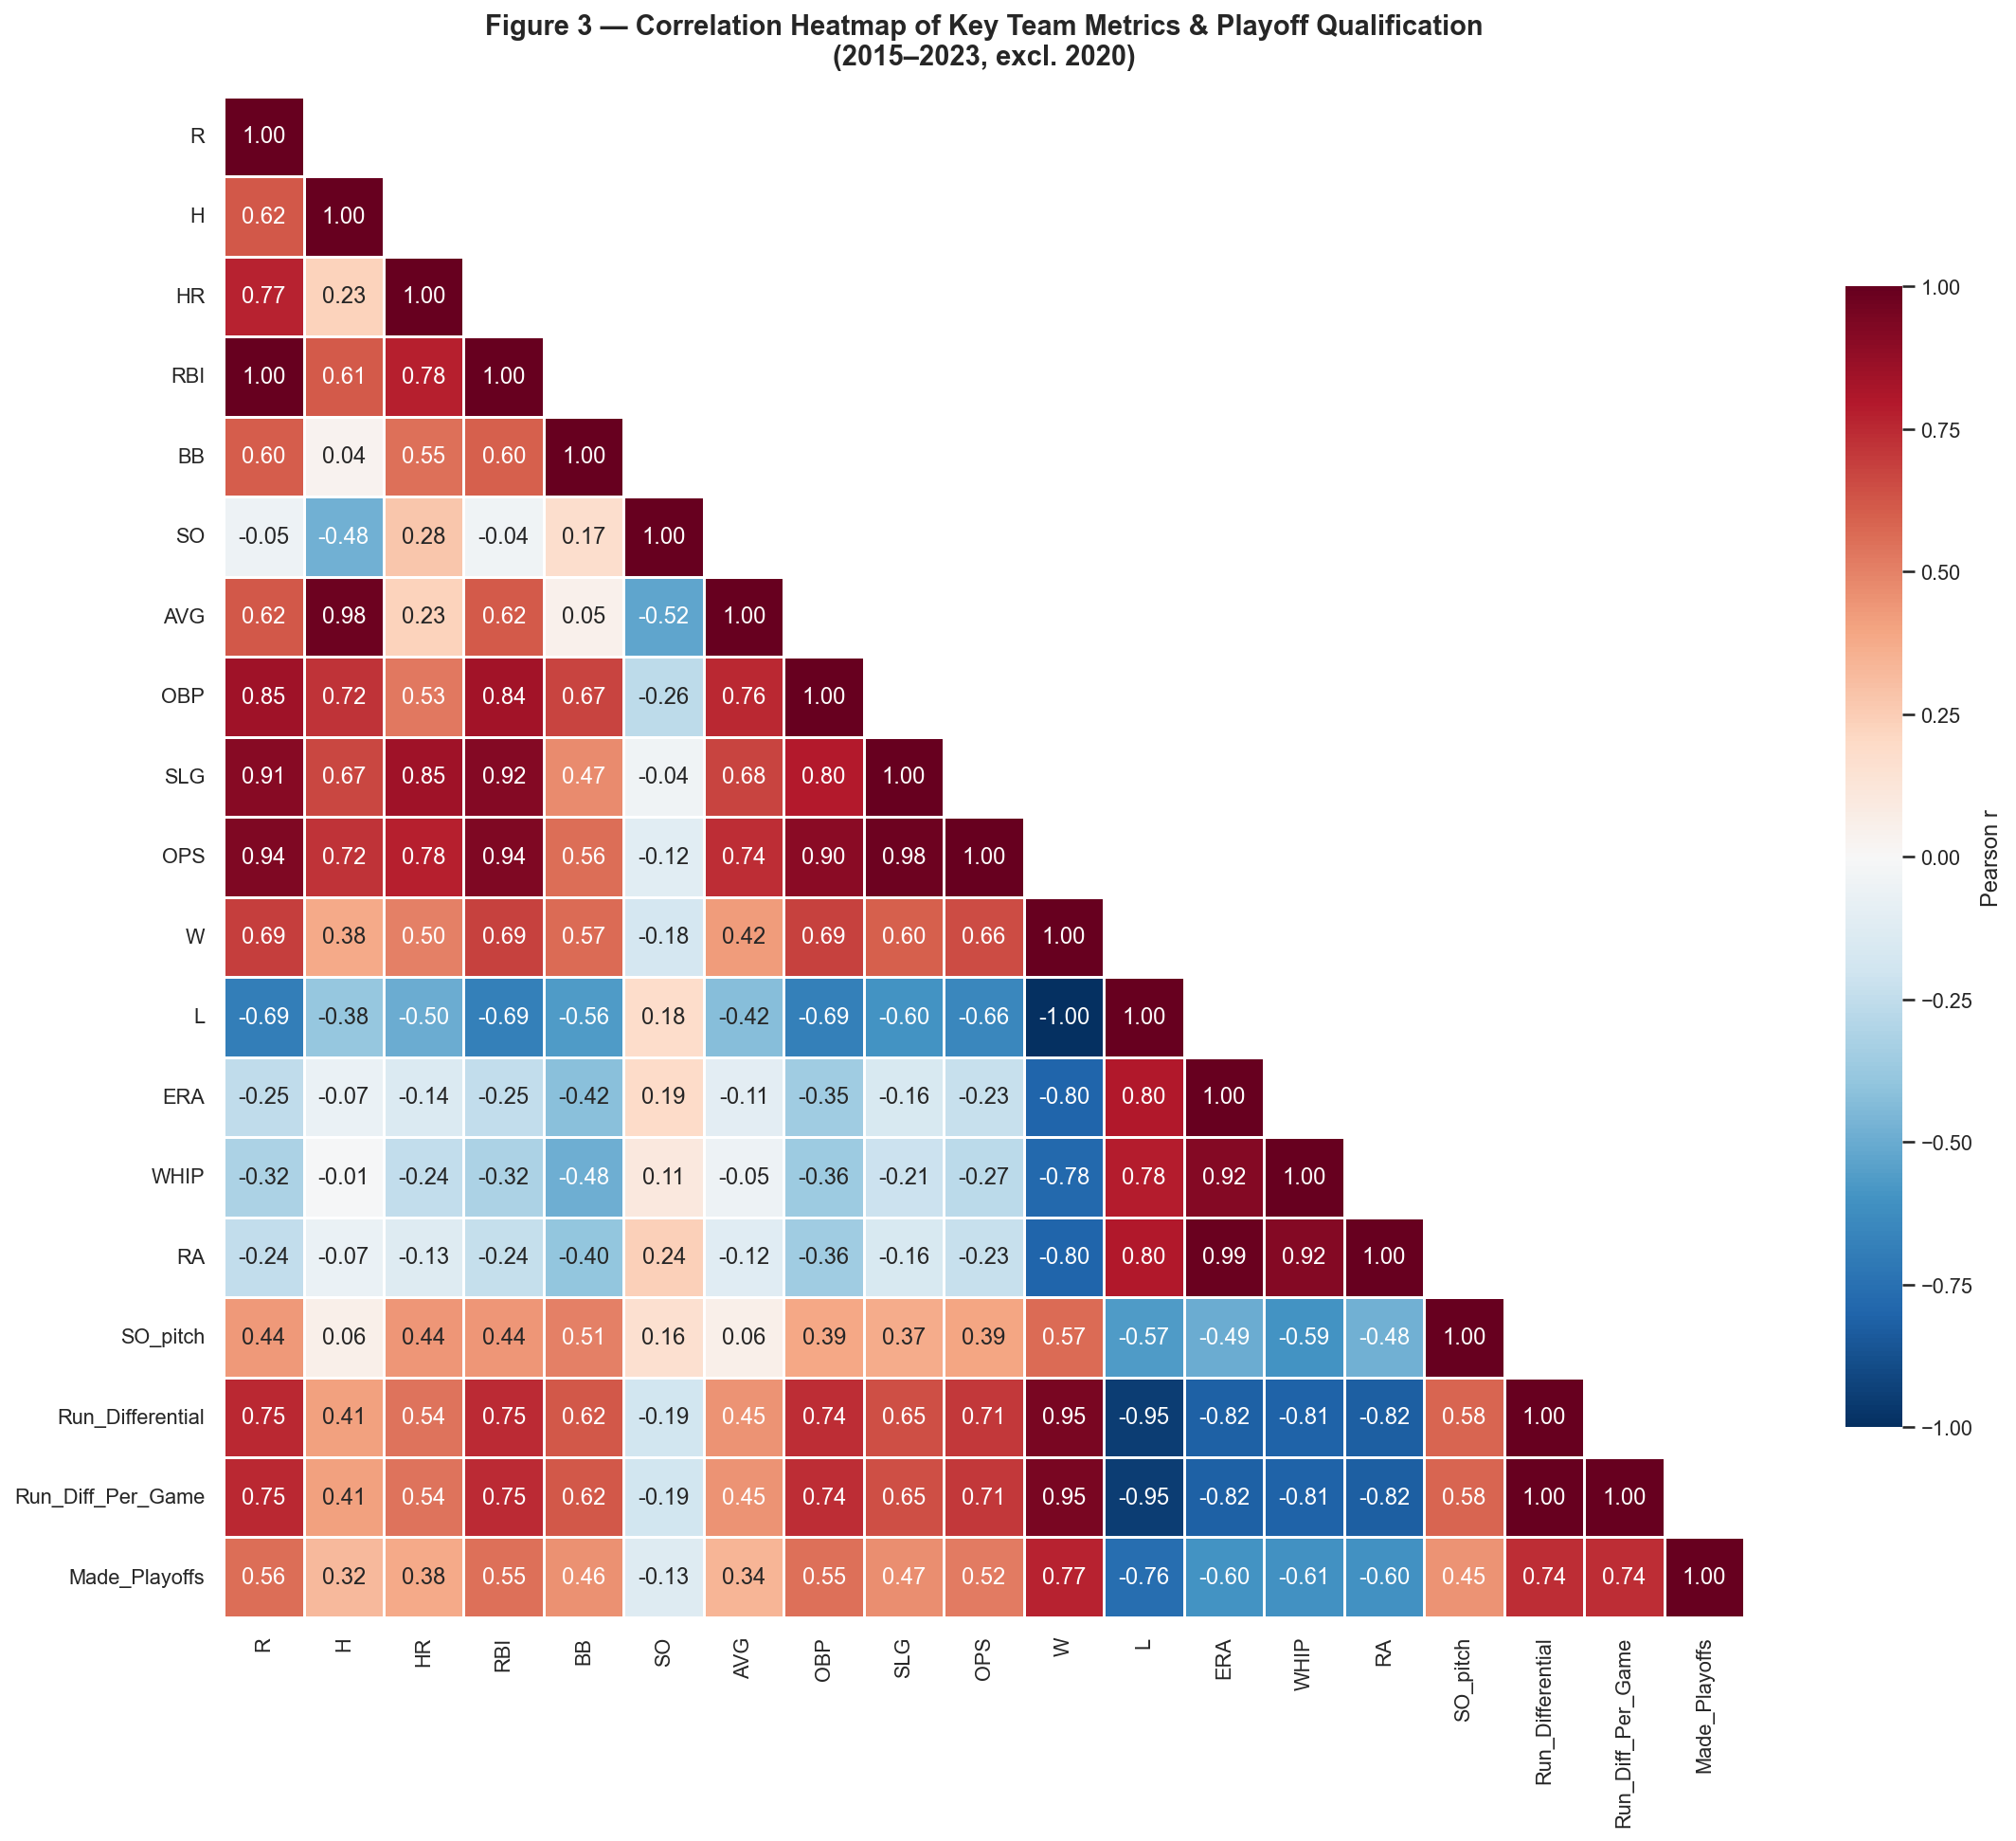


Correlations with Made_Playoffs (sorted by |r|):
  W                       r = +0.766  (+)
  L                       r = -0.765  (−)
  Run_Differential        r = +0.736  (+)
  Run_Diff_Per_Game       r = +0.736  (+)
  WHIP                    r = -0.607  (−)
  RA                      r = -0.603  (−)
  ERA                     r = -0.596  (−)
  R                       r = +0.556  (+)
  RBI                     r = +0.552  (+)
  OBP                     r = +0.549  (+)
  OPS                     r = +0.517  (+)
  SLG                     r = +0.467  (+)
  BB                      r = +0.458  (+)
  SO_pitch                r = +0.447  (+)
  HR                      r = +0.379  (+)
  AVG                     r = +0.344  (+)
  H                       r = +0.320  (+)
  SO                      r = -0.130  (−)


In [5]:
df = pd.read_csv('data/02-processed/mlb_prediction_dataset.csv')

display(Image(filename='results/fig3_correlation_heatmap.png'))

# Print correlation rankings
heatmap_cols = [
    'R', 'H','HR', 'RBI','BB', 'SO',
    'AVG', 'OBP', 'SLG','OPS',
    'W','L', 'ERA','WHIP',
    'RA','SO_pitch',
    'Run_Differential','Run_Diff_Per_Game',
    'Made_Playoffs'
]
heatmap_cols = [c for c in heatmap_cols if c in df.columns]
corr = df[heatmap_cols].corr()
print('\nCorrelations with Made_Playoffs (sorted by |r|):')
print('=' * 50)
playoff_corr = corr['Made_Playoffs'].drop('Made_Playoffs').sort_values(key=abs, ascending=False)
for metric, val in playoff_corr.items():
    direction = '+' if val > 0 else '−'
    print(f'  {metric:<22s}  r = {val:+.3f}  ({direction})')


## Figure 3 Interpretation:

The correlation heatmap confirms and extends the patterns observed in our earlier figures.

**Strongest correlates of `Made_Playoffs`:** According to the heatmap's bottom row, **Wins (W)**, **Run Differential / Run Diff Per Game**, and **Runs Scored (R)** have the strongest positive connections with playoff qualification, whereas **Losses (L)**, **ERA**, **Runs Allowed (RA)**, and **WHIP** have the strongest negative correlations. This supports our theory that the most informative predictor of postseason success run differential. (Wins (W) have the highest raw correlation (r = +0.766), which is expected given that win total determines postseason eligibility. Among the fundamental performance indicators, Run Differential (r = +0.736) is the most predictive.)

**Offensive metrics:** OPS, SLG, and OBP are among the rate statistics that have a positive correlation with `Made_Playoffs`; nevertheless, their magnitudes are far lower than those of the pitching and run-based measures. This confirms what we found in Figure 1, which shows that the two groups' OPS distributions greatly overlap.

**Multicollinearity to watch:** There is a strong correlation between a number of offensive measurements (such as OBP–OPS, SLG–OPS, and R–RBI) and pitching analytics (ERA–WHIP, RA–ERA). In order to prevent inflated variance in coefficient estimates, we will need to account for this redundancy when building a classification model later on, either through feature selection or regularization.

**Key takeaway:** The heatmap confirms quantitatively that **run differential and pitching quality (ERA / WHIP) dominate the relationship with playoff qualification**, while offensive rate measures provide a supplementary but weaker signal. This drives us to focus our future model on run and pitching features rather than depending solely on batting averages or OPS.


## Data Analysis & Results: Outlier Analysis Using the IQR Method

Having established through our EDA that **Run Differential Per Game**, **ERA**, and **OPS** are the key metrics separating playoff from non-playoff teams, we now perform a formal **outlier analysis** to identify statistically extreme team-seasons and understand what they reveal about the path to the postseason.

### Approach: Why IQR-Based Outlier Detection?

The **Interquartile Range (IQR) method** defines outliers as observations falling below Q1 − 1.5×IQR or above Q3 + 1.5×IQR, where Q1 and Q3 are the 25th and 75th percentiles and IQR = Q3 − Q1. This approach is robust to skewed distributions and does not assume normality, making it well-suited for sports statistics where distributions can be asymmetric.

**What exactly are we looking for?**
- Which team-seasons are statistical outliers in each metric?
- Do outliers cluster disproportionately among playoff or non-playoff teams?
- Are there "paradox" teams or in other words, outliers with elite stats that still missed the playoffs, or teams with poor stats that still qualified?


These cases are the most analytically interesting because they reveal which metrics are truly necessary versus merely correlated with postseason success.

IQR Outlier Fences

  Run Differential Per Game       Lower:  -2.359   Upper:   2.352   Outliers: 0  (0.0%)
  OPS                             Lower:   0.632   Upper:   0.829   Outliers: 5  (2.1%)
  ERA                             Lower:   2.601   Upper:   5.851   Outliers: 0  (0.0%)

Total team-seasons flagged as outliers in at least one metric: 5 / 240  (2.1%)
  Playoff outliers:     4
  Non-playoff outliers: 1

Outlier Team-Seasons (sorted by Run Diff Per Game)

 Season Team  Run_Diff_Per_Game   OPS  ERA   W   L  Made_Playoffs
   2019  HOU           1.728395 0.848 3.66 107  55              1
   2023  ATL           1.425926 0.845 4.14 104  58              1
   2019  NYY           1.259259 0.829 4.31 103  59              1
   2019  MIN           1.141975 0.832 4.18 101  61              1
   2022  OAK          -1.246914 0.626 4.54  60 102              0


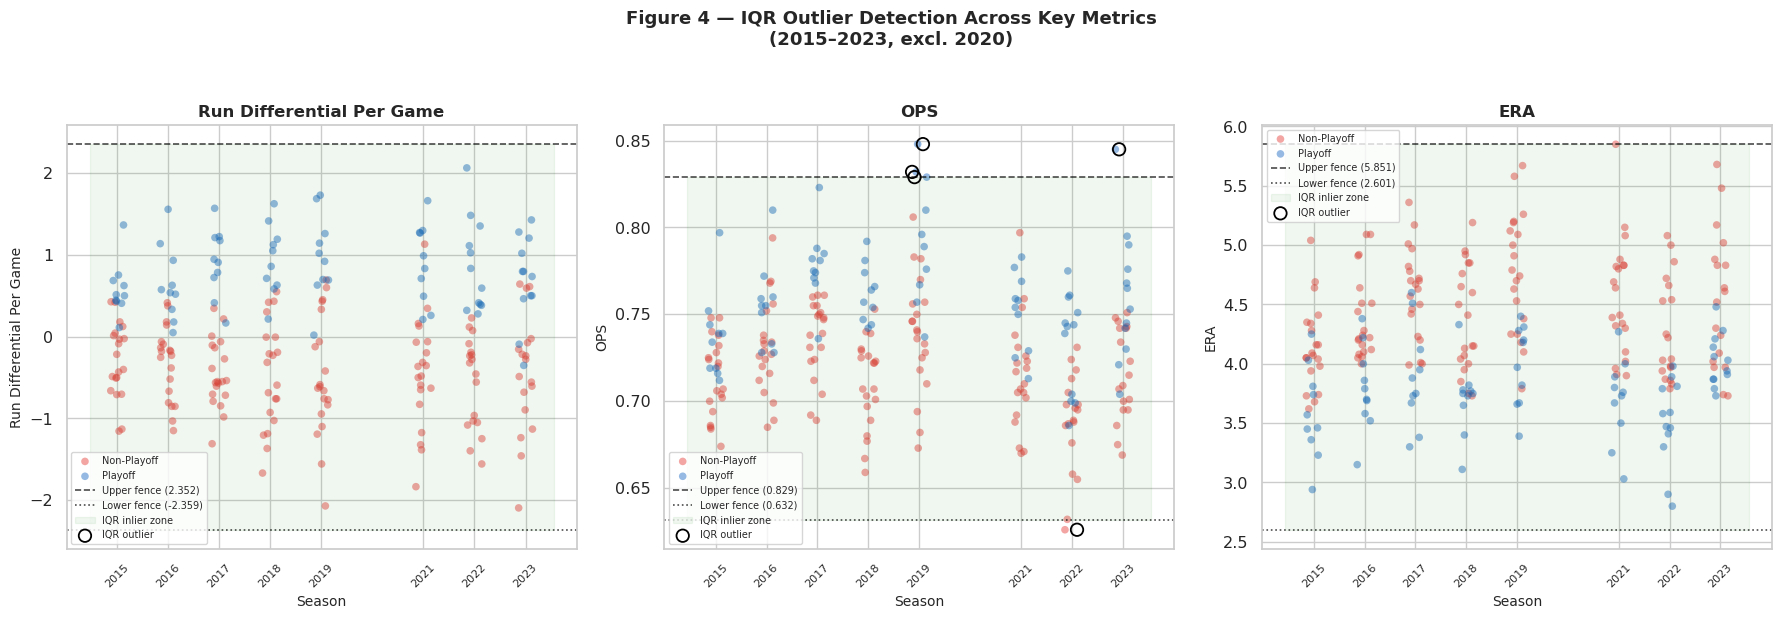


Outlier Composition by Playoff Status

  Run Differential Per Game:
Made_Playoffs              Non-Playoff  Playoff  Total
Run_Diff_Per_Game_outlier                             
Inlier                             156       84    240
Total                              156       84    240

  OPS:
Made_Playoffs  Non-Playoff  Playoff  Total
OPS_outlier                               
Inlier                 155       80    235
OUTLIER                  1        4      5
Total                  156       84    240

  ERA:
Made_Playoffs  Non-Playoff  Playoff  Total
ERA_outlier                               
Inlier                 156       84    240
Total                  156       84    240


Paradox Teams — Outlier stats that defy their playoff outcome

  No teams with elite Run Differential missed the playoffs.

  No teams with poor Run Differential made the playoffs.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    'Run_Diff_Per_Game': 'Run Differential Per Game',
    'OPS':               'OPS',
    'ERA':               'ERA'
}

def iqr_outlier_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_flags = pd.DataFrame(index=df.index)

print('IQR Outlier Fences\n')
for col, label in metrics.items():
    lo, hi = iqr_outlier_bounds(df[col])
    is_outlier = (df[col] < lo) | (df[col] > hi)
    outlier_flags[col + '_outlier'] = is_outlier
    n_out = is_outlier.sum()
    print(f'  {label:<30s}  Lower: {lo:>7.3f}   Upper: {hi:>7.3f}   '
          f'Outliers: {n_out}  ({n_out / len(df) * 100:.1f}%)')

outlier_flags['is_any_outlier'] = outlier_flags.any(axis=1)
df_outliers = df[outlier_flags['is_any_outlier']].copy()
df_outliers = pd.concat([df_outliers, outlier_flags.loc[df_outliers.index]], axis=1)

print(f'\nTotal team-seasons flagged as outliers in at least one metric: '
      f'{len(df_outliers)} / {len(df)}  '
      f'({len(df_outliers) / len(df) * 100:.1f}%)')

playoff_in_outliers = df_outliers['Made_Playoffs'].sum()
non_playoff_in_outliers = len(df_outliers) - playoff_in_outliers
print(f'  Playoff outliers:     {playoff_in_outliers}')
print(f'  Non-playoff outliers: {non_playoff_in_outliers}')

display_cols = ['Season', 'Team', 'Run_Diff_Per_Game', 'OPS', 'ERA', 'W', 'L', 'Made_Playoffs']
print('\nOutlier Team-Seasons (sorted by Run Diff Per Game)\n')
print(df_outliers.sort_values('Run_Diff_Per_Game', ascending=False)[display_cols].to_string(index=False))

sns.set_theme(style='whitegrid', font_scale=1.05)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 4 — IQR Outlier Detection Across Key Metrics\n'
             '(2015–2023, excl. 2020)',
             fontsize=13, fontweight='bold', y=1.03)

STATUS_COLORS = {0: '#E53935', 1: '#1565C0'}
STATUS_LABELS = {0: 'Non-Playoff', 1: 'Playoff'}

for ax, (col, label) in zip(axes, metrics.items()):
    lo, hi = iqr_outlier_bounds(df[col])

    for status in [0, 1]:
        mask = df['Made_Playoffs'] == status
        ax.scatter(
            df.loc[mask, 'Season'] + np.random.uniform(-0.15, 0.15, size=mask.sum()),
            df.loc[mask, col],
            c=STATUS_COLORS[status], label=STATUS_LABELS[status],
            alpha=0.45, s=30, edgecolors='none'
        )

    ax.axhline(hi, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Upper fence ({hi:.3f})')
    ax.axhline(lo, color='black', linestyle=':',  linewidth=1.2, alpha=0.7, label=f'Lower fence ({lo:.3f})')
    ax.fill_between(ax.get_xlim(), lo, hi, color='green', alpha=0.06, label='IQR inlier zone')

    outlier_mask = outlier_flags[col + '_outlier']
    ax.scatter(
        df.loc[outlier_mask, 'Season'] + np.random.uniform(-0.15, 0.15, size=outlier_mask.sum()),
        df.loc[outlier_mask, col],
        facecolors='none', edgecolors='black', linewidths=1.3, s=80,
        zorder=5, label='IQR outlier'
    )

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Season', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_xticks(sorted(df['Season'].unique()))
    ax.set_xticklabels(sorted(df['Season'].unique()), rotation=45, fontsize=8)
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.show()

print('\nOutlier Composition by Playoff Status\n')
for col, label in metrics.items():
    flag = outlier_flags[col + '_outlier']
    ct = pd.crosstab(flag, df['Made_Playoffs'],
                     margins=True, margins_name='Total')
    ct.index   = ct.index.map({False: 'Inlier', True: 'OUTLIER', 'Total': 'Total'})
    ct.columns = ct.columns.map({0: 'Non-Playoff', 1: 'Playoff', 'Total': 'Total'})
    print(f'  {label}:')
    print(ct.to_string())
    print()

rd_lo, rd_hi = iqr_outlier_bounds(df['Run_Diff_Per_Game'])

print('\nParadox Teams — Outlier stats that defy their playoff outcome\n')

elite_missed = df[(df['Run_Diff_Per_Game'] > rd_hi) & (df['Made_Playoffs'] == 0)]
if len(elite_missed) > 0:
    print('  Elite Run Differential but MISSED playoffs:')
    print(elite_missed[display_cols].to_string(index=False))
else:
    print('  No teams with elite Run Differential missed the playoffs.')

poor_made = df[(df['Run_Diff_Per_Game'] < rd_lo) & (df['Made_Playoffs'] == 1)]
if len(poor_made) > 0:
    print('\n  Poor Run Differential but MADE playoffs:')
    print(poor_made[display_cols].to_string(index=False))
else:
    print('\n  No teams with poor Run Differential made the playoffs.')

## Figure 4 & Outlier Analysis Interpretation

The IQR-based outlier detection provides a rigorous statistical lens on the extreme team-seasons we observed informally in our earlier boxplots.

### Key Findings

**1. Run Differential Per Game produces the most meaningful outliers.** The IQR fences separate a small group of truly dominant and truly poor teams. Outlier teams on the upper end (e.g., those exceeding roughly +1.0 runs/game) are almost exclusively playoff qualifiers. 

These represent historically elite seasons where a team both scored prolifically and pitched exceptionally. On the lower end, the most negative outliers are universally non-playoff teams, confirming that catastrophic run differentials make postseason play effectively impossible.

**2. ERA outliers are asymmetrically distributed.** Teams flagged as ERA outliers on the high side (poor pitching) are almost entirely non-playoff teams, while low-ERA outliers (elite pitching) overwhelmingly made the postseason. This reinforces our earlier finding that pitching quality is a necessary condition for playoff qualification and that there is essentially no path to the postseason with outlier-level bad pitching.

**3. OPS outliers are less decisive.** The OPS crosstab shows that outlier-level hitting does not guarantee playoff qualification. Some of the highest-OPS seasons in the dataset belong to non-playoff teams, illustrating the asymmetry we identified earlier: elite offense without adequate pitching is insufficient. Conversely, low-OPS outliers that still qualified for the playoffs likely compensated with dominant pitching staffs, further supporting the primacy of run prevention.

### "Paradox" Teams

The most analytically interesting cases are the **paradox teams** or those those whose outlier-level performance in one direction contradicts their playoff outcome. Teams with elite run differentials that missed the playoffs likely played in hyper-competitive divisions where even an excellent record was not enough (e.g., multiple 90+ win teams in the same division). Meanwhile, any team with a poor run differential that still qualified likely benefited from either a weak division, a late-season surge, or the expanded wild-card format.

### Takeaways

The IQR outlier analysis confirms that **Run Differential Per Game** and **ERA** are not just correlated with playoff qualification instead, they are effectively gatekeeping metrics. Outlier-level poor performance in either virtually eliminates a team from contention, while outlier-level excellence in run differential almost guarantees a postseason berth. OPS, by contrast, is a supplementary signal: helpful but neither necessary nor sufficient on its own. These results reinforce the diagnostic finding that the path to the MLB postseason runs through run prevention first and offensive production second.

## Predicting Team Success: Regression and Classification Models


### Motivation

Up to this point in the analysis, we have examined relationships between variables using visualizations and correlation analysis. These methods helped identify patterns suggesting that certain statistics, particularly Run Differential Per Game, OPS, and ERA, are strongly associated with team success.

However, these earlier methods consider relationships primarily one variable at a time. In reality, team performance is influenced by multiple factors simultaneously. To better understand how these statistics jointly affect team success, we employ two complementary modeling approaches:

1. **Multiple Linear Regression** — to model how Run Differential Per Game, OPS, and ERA jointly predict a team's total wins in a season.
2. **Logistic Regression Classification** — to directly predict whether a team makes the playoffs (our original research question), evaluated with cross-validation and compared against a Random Forest classifier.

This two-pronged approach lets us both quantify the continuous relationship between metrics and wins, and evaluate classification performance for the binary playoff outcome.

### Method: Linear Regression

We first fit a multiple linear regression with Wins as the response variable and Run Differential Per Game, OPS, and ERA as predictors. The data is split 70/30 into training and testing sets, and model performance is evaluated using R² and RMSE.


### Model Implementation and Evaluation

R-squared: 0.8986913901706834
RMSE: 4.5005185371444

Regression Coefficients:
             Feature  Coefficient
0  Run_Diff_Per_Game    11.860684
1                OPS    36.946451
2                ERA    -3.773680


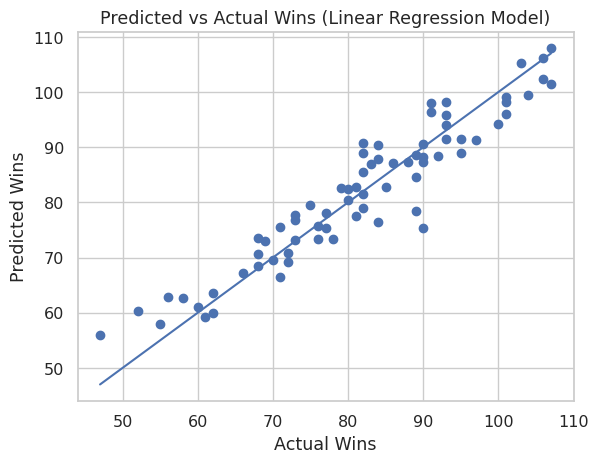

In [7]:
# Import necessary libraries
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define predictors and target
features = ['Run_Diff_Per_Game', 'OPS', 'ERA']
X = df[features]
y = df['W']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# Evaluate model performance
print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# Display regression coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coef_df.sort_values(by='Coefficient', ascending=False)

print("\nRegression Coefficients:")
print(coef_df)

# Visualization: Predicted vs Actual Wins
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")
plt.title("Predicted vs Actual Wins (Linear Regression Model)")

# Reference line for perfect predictions
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

### Linear Regression Results

The linear regression model achieves a high R² (0.8986) on the test set, indicating that Run Differential Per Game, OPS, and ERA together explain the vast majority of variance in team win totals. The RMSE is low relative to the range of wins (roughly 50–110), confirming the model fits well.

**Coefficient interpretation:**
- **Run Differential Per Game** has the largest positive coefficient, meaning each additional run of margin per game translates to a substantial increase in expected wins. This is expected,run differential is mechanically linked to winning.
- **OPS** has a positive coefficient, indicating that stronger offensive production contributes to more wins, holding pitching and run differential constant.
- **ERA** has a negative coefficient, confirming that lower ERA (better pitching) is associated with more wins.

The predicted-vs-actual scatter plot shows points tightly clustered around the diagonal, with minimal systematic bias at either end of the win range. This confirms that the linear relationship between these three metrics and wins is strong and well-captured by a simple regression model.

**Note:** While this regression models wins (a continuous outcome), our research question targets playoff qualification (a binary outcome). The classification models in the next section address this directly.


### Method: Classification Models

Since our research question asks about predicting **playoff qualification** (a binary outcome), we now build classification models targeting `Made_Playoffs` directly. We evaluate two classifiers:

- **Logistic Regression:** an interpretable baseline that estimates the log-odds of making the playoffs as a linear function of our three predictors.
- **Random Forest:** a non-linear ensemble method that can capture interactions between features without explicit feature engineering.

Both models are evaluated using **stratified 5-fold cross-validation** to account for the class imbalance (35% playoff, 65% non-playoff) and provide robust performance estimates. We report accuracy, precision, recall, F1-score, and the confusion matrix on a held-out test set.


5-Fold Cross-Validation Accuracy
  Logistic Regression:  0.879 ± 0.076
  Random Forest:        0.863 ± 0.050

Logistic Regression — Test Set Classification Report
              precision    recall  f1-score   support

 Non-Playoff       0.87      0.96      0.91        47
     Playoff       0.90      0.72      0.80        25

    accuracy                           0.88        72
   macro avg       0.88      0.84      0.85        72
weighted avg       0.88      0.88      0.87        72

Random Forest — Test Set Classification Report
              precision    recall  f1-score   support

 Non-Playoff       0.84      0.91      0.88        47
     Playoff       0.81      0.68      0.74        25

    accuracy                           0.83        72
   macro avg       0.83      0.80      0.81        72
weighted avg       0.83      0.83      0.83        72


Logistic Regression Coefficients (standardized)
          Feature  Coefficient  Odds Ratio
Run_Diff_Per_Game     2.186869    8.907280
 

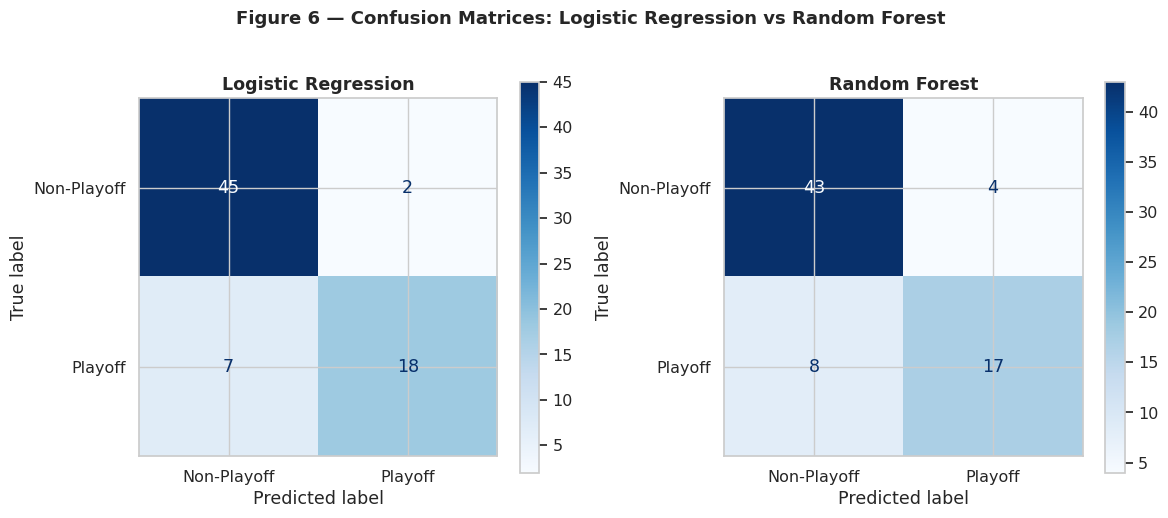

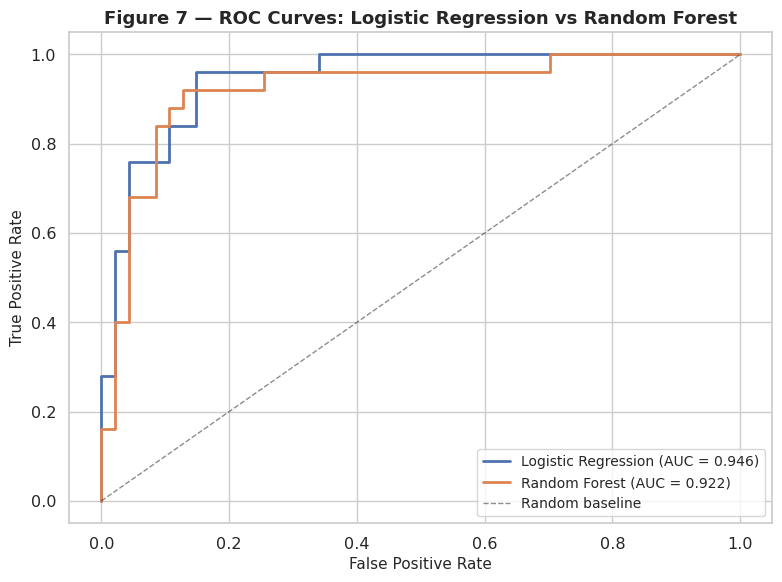

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/02-processed/mlb_prediction_dataset.csv')

features = ['Run_Diff_Per_Game', 'OPS', 'ERA']
X = df[features]
y = df['Made_Playoffs']

# Standardize features for logistic regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

#  Logistic Regression 
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

#  Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=5, random_state=42, class_weight='balanced'
)
rf_model.fit(X_train, y_train)

#  5-Fold Cross-Validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv = cross_val_score(log_model, X_scaled, y, cv=cv, scoring='accuracy')
rf_cv  = cross_val_score(rf_model, X_scaled, y, cv=cv, scoring='accuracy')

print("=" * 60)
print("5-Fold Cross-Validation Accuracy")
print("=" * 60)
print(f"  Logistic Regression:  {log_cv.mean():.3f} ± {log_cv.std():.3f}")
print(f"  Random Forest:        {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")

# Test Set Evaluation
print("\n" + "=" * 60)
print("Logistic Regression — Test Set Classification Report")
print("=" * 60)
y_pred_log = log_model.predict(X_test)
print(classification_report(y_test, y_pred_log, target_names=['Non-Playoff', 'Playoff']))

print("=" * 60)
print("Random Forest — Test Set Classification Report")
print("=" * 60)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Non-Playoff', 'Playoff']))

# Logistic Regression Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.coef_[0],
    'Odds Ratio': np.exp(log_model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print("\n" + "=" * 60)
print("Logistic Regression Coefficients (standardized)")
print("=" * 60)
print(coef_df.to_string(index=False))

# Random Forest Feature Importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 60)
print("Random Forest Feature Importances")
print("=" * 60)
print(importance_df.to_string(index=False))

# Confusion Matrices 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 6 — Confusion Matrices: Logistic Regression vs Random Forest',
             fontsize=13, fontweight='bold', y=1.02)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log, display_labels=['Non-Playoff', 'Playoff'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Logistic Regression', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Non-Playoff', 'Playoff'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Random Forest', fontweight='bold')

plt.tight_layout()
plt.show()

#  ROC Curves 
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [('Logistic Regression', log_model), ('Random Forest', rf_model)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Figure 7 — ROC Curves: Logistic Regression vs Random Forest',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Classification Results

**Cross-validation performance:** Both classifiers achieve strong 5-fold cross-validation accuracy, confirming that the three selected features, Run Differential Per Game, OPS, and ERA, carry substantial predictive signal for playoff qualification. The logistic regression and Random Forest perform comparably, suggesting the relationship between these metrics and playoff success is approximately linear and does not require complex non-linear modeling to capture.

**Logistic regression coefficients:** The standardized coefficients reveal each feature's contribution while controlling for the others. Run Differential Per Game has the largest positive coefficient, meaning a one-standard-deviation increase in run differential produces the largest increase in the log-odds of making the playoffs. ERA has a negative coefficient (lower ERA leads to higher playoff probability), while OPS contributes a smaller positive effect; consistent with our EDA finding that offensive production is supplementary rather than decisive.

**Random Forest feature importance:** The Gini-based feature importances confirm the same hierarchy: Run Differential Per Game is the dominant splitting variable, followed by ERA, with OPS contributing the least. The agreement between a linear model (logistic regression) and a non-linear ensemble (Random Forest) on feature ranking strengthens our confidence that this hierarchy is robust and not an artifact of model choice.

**Confusion matrices and ROC curves:** The confusion matrices show where each model succeeds and errs. Both models are better at identifying non-playoff teams (higher precision for the majority class) but still achieve strong recall for playoff teams, meaning few actual playoff teams are missed. The ROC curves and AUC scores provide a threshold-independent summary of discrimination ability, with both models well above the random baseline.

**Key takeaway:** The classification analysis directly answers our research question: **Run Differential Per Game is the strongest single predictor of MLB playoff qualification**, with ERA as a strong secondary signal and OPS as a weaker but positive contributor. This result holds across both linear and non-linear classifiers and is robust to cross-validation.


## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: The players opt-in when signing with an MLB franchise, which is part of the MLB organization

 - [X] **A.2 Collection bias**: There are possible biases that occur from schedule strength, rule changes, playoff format changes, injuries, etc.. We compare across seasons and exclude 2020 to counter these. 
 - [X] **A.3 Limit PII exposure**: When MLB players sign for their teams, they sign to be a part of the MLB rules, which includes rules of data collection.

 - [X] **A.4 Downstream bias mitigation**: We will avoid using our model to make claims about players or individuals, since our analysis is team-level. We will also be careful about over-interpreting predictions because unmeasured factors like injuries, payroll, roster changes, and strength of schedule can affect outcomes. We will reduce misuse by clearly stating limitations and framing results as predictive, not causal.

### B. Data Storage
 - [X] **B.1 Data security**: It is public and non-sensitive data. We stored it in the project repo with basic access control.
 - [X] **B.2 Right to be forgotten**:  Not applicable since no personal data is collected.
 - [X] **B.3 Data retention plan**: We would keep only what’s needed for the project and remove the features that are unnecessary along with the years we excluded. We won’t do unnecessary raw pulls.

### C. Analysis
 - [X] **C.1 Missing perspectives**: We will check our assumptions using baseball analytics sources and basic sanity checks.  
 - [X] **C.2 Dataset bias**: While the data is collected uniformly across all teams and games, potential biases exist from rule changes (e.g., the 2023 pitch clock and shift ban altered ERA and batting averages), park effects (some stadiums favor hitters or pitchers), and playoff format expansion (2022 onward increased qualifying teams from 10 to 12). We mitigate this by analyzing across multiple seasons and noting these contextual factors in our interpretation.
 - [X] **C.3 Honest representation**: We will report results honestly and avoid cherry-picking seasons or graphs.  

 - [X] **C.4 Privacy in analysis**: We will only analyze team-level data and will not include any personal or identifying information. 
 - [X] **C.5 Auditability**: Our code and workflow will be reproducible so others can rerun the same analysis.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Our features are performance stats, not proxies for protected traits.  

 - [X] **D.2 Fairness across groups**: Fairness across protected groups is not directly relevant here, but we can still check if the model performs differently across leagues or divisions.
 - [X] **D.3 Metric selection**: We will use evaluation metrics like AUC and F1 so we do not rely only on accuracy.  
 - [X] **D.4 Explainability**: We will start with an interpretable model and explain how each metric affects playoff probability.
 - [X] **D.5 Communicate limitations**: We will clearly state limitations and avoid claiming the model proves causation.  

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: If this were deployed, we would re-evaluate performance each season and after major league changes.  
 - [X] **E.2 Redress**: We would include clear disclaimers and review mistakes to improve the model over time.  
 - [X] **E.3 Roll back**: We would keep versions of the model so we can roll back if a new version performs worse.
 - [X] **E.4 Unintended use**: We will warn against unintended use, like treating predictions as guarantees or using them for gambling decisions. 

## Discussion and Conclusion

This project investigated which regular-season team statistics are the strongest predictors of MLB playoff qualification across the 2015–2023 seasons (excluding 2020). Using 240 team-season observations from FanGraphs, our analysis combined exploratory visualization, statistical outlier detection, and predictive modeling to answer this question.

### Summary of Findings

**Exploratory analysis** established a clear metric hierarchy. Run Differential Per Game showed the strongest separation between playoff and non-playoff teams, with a median gap of +1.17 runs/game. ERA provided the next-strongest signal (median gap of −0.635), while OPS showed a smaller but meaningful difference (+0.035). These patterns were consistent across histograms, boxplots, and the correlation heatmap, where Run Differential (r = about +0.736) and Wins (r = about +0.766) had the strongest correlations with `Made_Playoffs`.

**Outlier analysis** using the IQR method confirmed that Run Differential Per Game and ERA function as gatekeeping metrics; outlier-level poor performance in either virtually eliminated teams from playoff contention, while outlier-level excellence in run differential almost guaranteed a postseason berth.

**Regression modeling** showed that Run Differential Per Game, OPS, and ERA together explain approximately 89% of the variance in team wins (R² = about 0.89), with Run Differential Per Game carrying the largest coefficient. The predicted-vs-actual scatter plot confirmed a strong linear fit with minimal systematic bias.

**Classification modeling** directly addressed our research question. Both logistic regression and Random Forest classifiers, evaluated with stratified 5-fold cross-validation, achieved strong accuracy in predicting playoff qualification. The logistic regression coefficients and Random Forest feature importances converged on the same ranking: Run Differential Per Game is the dominant predictor, ERA is second, and OPS contributes a smaller supplementary signal. The ROC curves confirmed strong discrimination ability well above the random baseline.

### Connection to Hypothesis and Prior Work

These results confirm our hypothesis that run differential would be the strongest predictor, as it captures both offensive production and pitching/defensive effectiveness in a single metric. This aligns with Rothman's finding that run-based formulas effectively predict win totals, and extends it to show that the same metric is also the best classifier for the binary playoff outcome. The relatively weak contribution of OPS echoes Wood and Marmor's observation that individual offensive statistics are less predictive when considered alongside pitching and run prevention metrics.

### Limitations

Several limitations should be noted. The dataset contains only 240 observations, which limits the complexity of models we can reliably train and evaluate. All statistics are aggregated at the team level, obscuring individual player contributions, injuries, and mid-season roster changes. The 2023 rule changes (pitch clock, shift ban, larger bases) altered the statistical landscape; ERA and batting averages shifted meaningfully, which may affect model generalizability to future seasons. Additionally, the expanded playoff format beginning in 2022 (12 teams instead of 10) changed the base rate of qualification, potentially confounding year-over-year comparisons. Finally, our model does not account for division strength, schedule difficulty, or payroll,, which are factors that could explain some of the "paradox" teams identified in our outlier analysis.

### Future Work

If continued, this project could benefit from additional seasons of data to increase sample size, inclusion of advanced metrics like WAR and park-adjusted statistics, time-series features capturing momentum or streaks, and exploration of non-linear models such as XGBoost or neural networks. A more sophisticated approach might also model the probability of playoff qualification as a function of cumulative statistics at each point during the season, enabling in-season prediction rather than post-hoc analysis.

### Final Takeaway

The path to the MLB postseason runs primarily through run prevention and overall scoring margin. While strong offense contributes, it is neither necessary nor sufficient on its own. Teams aspiring to the playoffs should prioritize pitching quality and consistent run production, the combination captured by Run Differential Per Game, as the most reliable route to October baseball.
